# import

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa,librosa.display
import IPython.display as ipd
import soundfile as sf
import os


In [20]:
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

In [21]:
from huggingface_hub import login

login()

     Downloaded the words classes from Hugging Face and generated words dataset


In [23]:
import time
from huggingface_hub import snapshot_download
word_classes = [
    "Alam", "Arnab", "Asfour", "Assal", "Bab", "Bathenjan",
    "Beit", "Dabet", "Dalu", "Daraj", "Defda", "Ders", "Dob",
    "Ein", "Fam", "Farasha", "Feel", "Ghaba", "Ghaima", "Ghazal",
    "Hadeka", "Hadeya", "Halib", "Hasoub", "Hatef", "Helal",
    "Jamal", "Jaras", "Jondy", "Kalb", "Ketab", "Khait",
    "Kharouf", "Khobz", "Kora", "Lahma", "Lesan", "Maa",
    "Masjed", "Meqas", "Nafetha", "Najm", "Namla", "Om",
    "Patta", "Qalam", "Qamar", "Qerd", "Raml","Romman",
    "Saqer","Sennara","Shajara", "Shams","Zarafa"
]

local_root = r"E:\baby_developer\words_abjad_kids_dataset\abjad_words"
log_file = os.path.join(local_root,"download_progress.txt")

os.makedirs(local_root, exist_ok=True)

completed = set()

if os.path.exists(log_file):

    with open(log_file, "r") as f:
        completed = set(
            line.strip()
            for line in f
            if line.strip()
        )


print(
    f"Already Done: "
    f"{len(completed)} / {len(word_classes)}\n"
)

MAX_RETRIES = 5
BASE_WAIT = 15 # second - delay before the next download

failed = []


for i, word in enumerate(word_classes, 1):

    # Skip already downloaded classes
    if word in completed:

        print(
            f"[{i}/{len(word_classes)}] "
            f"{word} - skip (already exists)"
        )

        continue


    success = False


    # Retry if download fails
    for attempt in range(
        1,
        MAX_RETRIES + 1
    ):

        print(
            f"[{i}/{len(word_classes)}] "
            f"{word} "
            f"(try {attempt}/{MAX_RETRIES}) ..."
        )


        try:

            snapshot_download(
                repo_id="Aziz-snoubra/Abjad-Kids",
                repo_type="dataset",
                allow_patterns=[f"alphabet/{word}/**"],
                local_dir=local_root
            )

            # Save successful download
            with open(
                log_file,
                "a"
            ) as f:

                f.write(
                    word + "\n"
                )


            print(
                f"Done: {word}"
            )


            success = True
            break


        except Exception as e:

            error_msg = str(e)


            # Handle Hugging Face rate limit
            if "429" in error_msg:

                wait_time = (
                    BASE_WAIT *
                    (2 ** (attempt - 1))
                )

                print(
                    f"429 Too Many Requests - "
                    f"try again after "
                    f"{wait_time} seconds..."
                )

                time.sleep(
                    wait_time
                )


            else:

                print(
                    f"Error: {error_msg}"
                )

                time.sleep(5)

    if not success:
        failed.append(word)

        print(
            f"Completely failed after "
            f"{MAX_RETRIES} attempts: "
            f"{word}"
        )

    # Delay between downloads
    time.sleep(
        BASE_WAIT
    )

print("\n==========")


completed_now = set()

if os.path.exists(log_file):

    with open(
        log_file,
        "r"
    ) as f:

        completed_now = set(
            line.strip()
            for line in f
            if line.strip()
        )


print(
    "Successfully downloaded:",
    len(completed_now)
)

print(
    "Failed:",
    len(failed)
)


if failed:

    print(
        "\nFailed word classes:"
    )

    for word in failed:
        print(
            "-",
            word
        )

else:

    print(
        "\nAll word classes downloaded successfully!"
    )

Already Done: 55 / 55

[1/55] Alam - skip (already exists)
[2/55] Arnab - skip (already exists)
[3/55] Asfour - skip (already exists)
[4/55] Assal - skip (already exists)
[5/55] Bab - skip (already exists)
[6/55] Bathenjan - skip (already exists)
[7/55] Beit - skip (already exists)
[8/55] Dabet - skip (already exists)
[9/55] Dalu - skip (already exists)
[10/55] Daraj - skip (already exists)
[11/55] Defda - skip (already exists)
[12/55] Ders - skip (already exists)
[13/55] Dob - skip (already exists)
[14/55] Ein - skip (already exists)
[15/55] Fam - skip (already exists)
[16/55] Farasha - skip (already exists)
[17/55] Feel - skip (already exists)
[18/55] Ghaba - skip (already exists)
[19/55] Ghaima - skip (already exists)
[20/55] Ghazal - skip (already exists)
[21/55] Hadeka - skip (already exists)
[22/55] Hadeya - skip (already exists)
[23/55] Halib - skip (already exists)
[24/55] Hasoub - skip (already exists)
[25/55] Hatef - skip (already exists)
[26/55] Helal - skip (already exists)

    split file name  to : class /file name/child_id/record_id=UUID/copy_num / file hash

In [42]:
import re
import hashlib

words_path = r"E:\baby_developer\words_abjad_kids_dataset\abjad_words\alphabet"

uuid_pattern = re.compile(
    r'[0-9a-fA-F]{8}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{12}'
)

words_data = []

for class_name in os.listdir(words_path):

    class_path = os.path.join(words_path, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):

        if not file_name.lower().endswith(".wav"):
            continue

        name_without_ext = os.path.splitext(file_name)[0]

        match = uuid_pattern.search(name_without_ext)

        if match:

            recording_id = match.group()

            before_uuid = name_without_ext[
                :match.start()
            ].rstrip("_")

            after_uuid = name_without_ext[
                match.end():
            ].lstrip("_")

            # Extract child_id
            if before_uuid.startswith(class_name + "_"):
                child_id = before_uuid[
                    len(class_name) + 1:
                ]
            else:
                child_id = before_uuid

            copy_num = (
                after_uuid
                if after_uuid
                else "1"
            )

        else:

            child_id = "UNKNOWN"
            recording_id = "UNKNOWN"
            copy_num = "UNKNOWN"

        # File path
        file_path = os.path.join(
            class_path,
            file_name
        )

        # Calculate MD5 hash to check if duplicated files exist
        hash_md5 = hashlib.md5()

        with open(file_path, "rb") as f:

            for chunk in iter(
                lambda: f.read(4096),
                b""
            ):
                hash_md5.update(chunk)

        file_hash = hash_md5.hexdigest()

        words_data.append({
            "class": class_name,
            "file_name": file_name,
            "child_id": child_id,
            "recording_id": recording_id,
            "copy_num": copy_num,
            "file_hash": file_hash
        })


words_data = pd.DataFrame(words_data)

print("Total files:", len(words_data))
print("Total classes:", words_data["class"].nunique())
print("Total children:", words_data["child_id"].nunique())
print("Unknown children:",
      (words_data["child_id"] == "UNKNOWN").sum())

display(words_data.head(10))

Total files: 9019
Total classes: 55
Total children: 166
Unknown children: 0


,class,file_name,child_id,recording_id,copy_num,file_hash
0,Alam,Alam_adam khatab_b5cf27cc-0748-484e-95f3-59c81...,adam khatab,b5cf27cc-0748-484e-95f3-59c81ae94514,1,66046008dd77a5aaab44cfc53094f7ec
1,Alam,Alam_bilad_1c5b4960-2f93-45e7-bae2-b0dd175990c...,bilad,1c5b4960-2f93-45e7-bae2-b0dd175990c4,1,08dbb6416576fdd81d66b90c3435383b
2,Alam,Alam_bilad_a266a5d9-976d-4b7b-b749-9dfabe4f039...,bilad,a266a5d9-976d-4b7b-b749-9dfabe4f0395,1,4da90a9d247329991ae877c5326c09a0
3,Alam,Alam_fahd_000e62c5-9013-4736-b25b-b806d4f126c3...,fahd,000e62c5-9013-4736-b25b-b806d4f126c3,1,28ed6559bdd37252428c6518cf281691
4,Alam,Alam_fahd_e971457c-c41b-47fa-a99d-5b9df41817ec...,fahd,e971457c-c41b-47fa-a99d-5b9df41817ec,1,acc3e4ec84d6cfa5c5b8230485bd5b8a
5,Alam,Alam_fawaz mohamad_5dd11752-c280-4910-8747-eb9...,fawaz mohamad,5dd11752-c280-4910-8747-eb98950f3413,1,0789d9182256e239af9a29f398abca9d
6,Alam,Alam_fawaz mohamad_6e724d94-3277-4c98-b7db-904...,fawaz mohamad,6e724d94-3277-4c98-b7db-90415a5f755a,1,90ca386300d0c14e7ed56e0da1db1814
7,Alam,Alam_imad alzabiq_666e60e8-2c9c-4a95-92b0-13b4...,imad alzabiq,666e60e8-2c9c-4a95-92b0-13b4a3bcb78a,1,3ec0898246e26cc7a0f4f476d3658c4f
8,Alam,Alam_imad alzabiq_f1a76579-352a-45d6-8607-f862...,imad alzabiq,f1a76579-352a-45d6-8607-f862db780d54,1,0e9ec6f400587a455e573fa535ac6e96
9,Alam,Alam_joo_74bbc4f8-5af4-4a73-a4aa-4e573b5aa364.wav,joo,74bbc4f8-5af4-4a73-a4aa-4e573b5aa364,1,7105f563381a73b51247720d83027213


    remove duplicated files 

In [25]:
#Find Duplicate Files
duplicate_groups = (
    words_data
    .groupby(
        ["class", "child_id", "recording_id", "file_hash"]
    )
    .agg(
        num_copies=("file_name", "count"),
        files=("file_name", list)
    )
    .reset_index()
)

# Keep only groups that have duplicates
duplicated_files = duplicate_groups[
    duplicate_groups["num_copies"] > 1
].copy()

print("Total duplicated groups:",len(duplicated_files))

print("Duplicate files to remove:",
      duplicated_files["num_copies"].sub(1).sum())

print("Files to keep:",
      len(duplicated_files))

# display sample 
if len(duplicated_files) > 0:
    print("\nSample of duplicated files:")
    display(
        duplicated_files.head(10)
        .style
        .hide(axis="index")
    )
else:
    print("\nNo duplicate files found.")

Total duplicated groups: 5827
Duplicate files to remove: 7104
Files to keep: 5827

Sample of duplicated files:


class,child_id,recording_id,file_hash,num_copies,files
Alam,adam khatab,b5cf27cc-0748-484e-95f3-59c81ae94514,66046008dd77a5aaab44cfc53094f7ec,3,"['Alam_adam khatab_b5cf27cc-0748-484e-95f3-59c81ae94514.wav', 'Alam_adam khatab_b5cf27cc-0748-484e-95f3-59c81ae94514_2.wav', 'Alam_adam khatab_b5cf27cc-0748-484e-95f3-59c81ae94514_3.wav']"
Alam,fawaz mohamad,5dd11752-c280-4910-8747-eb98950f3413,0789d9182256e239af9a29f398abca9d,3,"['Alam_fawaz mohamad_5dd11752-c280-4910-8747-eb98950f3413.wav', 'Alam_fawaz mohamad_5dd11752-c280-4910-8747-eb98950f3413_2.wav', 'Alam_fawaz mohamad_5dd11752-c280-4910-8747-eb98950f3413_3.wav']"
Alam,fawaz mohamad,6e724d94-3277-4c98-b7db-90415a5f755a,90ca386300d0c14e7ed56e0da1db1814,3,"['Alam_fawaz mohamad_6e724d94-3277-4c98-b7db-90415a5f755a.wav', 'Alam_fawaz mohamad_6e724d94-3277-4c98-b7db-90415a5f755a_2.wav', 'Alam_fawaz mohamad_6e724d94-3277-4c98-b7db-90415a5f755a_3.wav']"
Alam,imad alzabiq,666e60e8-2c9c-4a95-92b0-13b4a3bcb78a,3ec0898246e26cc7a0f4f476d3658c4f,3,"['Alam_imad alzabiq_666e60e8-2c9c-4a95-92b0-13b4a3bcb78a.wav', 'Alam_imad alzabiq_666e60e8-2c9c-4a95-92b0-13b4a3bcb78a_2.wav', 'Alam_imad alzabiq_666e60e8-2c9c-4a95-92b0-13b4a3bcb78a_3.wav']"
Alam,imad alzabiq,f1a76579-352a-45d6-8607-f862db780d54,0e9ec6f400587a455e573fa535ac6e96,3,"['Alam_imad alzabiq_f1a76579-352a-45d6-8607-f862db780d54.wav', 'Alam_imad alzabiq_f1a76579-352a-45d6-8607-f862db780d54_2.wav', 'Alam_imad alzabiq_f1a76579-352a-45d6-8607-f862db780d54_3.wav']"
Alam,karam hakim,55631b1b-f263-4d51-bbc3-e525d8eee4b3,393dec3035eb5f2a849c47c70f54160c,3,"['Alam_karam hakim_55631b1b-f263-4d51-bbc3-e525d8eee4b3.wav', 'Alam_karam hakim_55631b1b-f263-4d51-bbc3-e525d8eee4b3_2.wav', 'Alam_karam hakim_55631b1b-f263-4d51-bbc3-e525d8eee4b3_3.wav']"
Alam,karam hakim,b24387c2-a364-41f2-8518-1fac981def93,22cebc5e25979d22e6fdbc37a563c01f,3,"['Alam_karam hakim_b24387c2-a364-41f2-8518-1fac981def93.wav', 'Alam_karam hakim_b24387c2-a364-41f2-8518-1fac981def93_2.wav', 'Alam_karam hakim_b24387c2-a364-41f2-8518-1fac981def93_3.wav']"
Alam,limar maghrbi,9c8e8739-f764-4fda-97b3-fb613b4b5d63,6e7491dec68c44651520d85d56f55ddb,3,"['Alam_limar maghrbi_9c8e8739-f764-4fda-97b3-fb613b4b5d63.wav', 'Alam_limar maghrbi_9c8e8739-f764-4fda-97b3-fb613b4b5d63_2.wav', 'Alam_limar maghrbi_9c8e8739-f764-4fda-97b3-fb613b4b5d63_3.wav']"
Alam,limar maghrbi,cd221455-5273-495d-89e4-7b28fa1390b5,1109f898fad846917ebef004d0a9c157,3,"['Alam_limar maghrbi_cd221455-5273-495d-89e4-7b28fa1390b5.wav', 'Alam_limar maghrbi_cd221455-5273-495d-89e4-7b28fa1390b5_2.wav', 'Alam_limar maghrbi_cd221455-5273-495d-89e4-7b28fa1390b5_3.wav']"
Alam,lya alalmian,2a5d409b-55ae-497b-bb9b-965dd4135039,e18a12c08789ebb1286eb0da9a28fb02,3,"['Alam_lya alalmian_2a5d409b-55ae-497b-bb9b-965dd4135039.wav', 'Alam_lya alalmian_2a5d409b-55ae-497b-bb9b-965dd4135039_2.wav', 'Alam_lya alalmian_2a5d409b-55ae-497b-bb9b-965dd4135039_3.wav']"


In [31]:
# Delete Duplicate Copies
files_to_delete = []
files_to_keep = []

for _, row in duplicated_files.iterrows():

    class_name = row["class"]
    
    # Sort files to make the kept copy deterministic
    files_list = sorted(row["files"])

    # Keep the first file
    files_to_keep.append(files_list[0])

    # Delete the remaining copies
    files_to_delete.extend(files_list[1:])

print("Files that will be deleted:",
      len(files_to_delete))

print("Files that will be kept:",
      len(files_to_keep))

# Preview Files Before Deletion
for file_path in files_to_delete[:10]:
    print("\n",file_path)

Files that will be deleted: 7104
Files that will be kept: 5827

 Alam_adam khatab_b5cf27cc-0748-484e-95f3-59c81ae94514_2.wav

 Alam_adam khatab_b5cf27cc-0748-484e-95f3-59c81ae94514_3.wav

 Alam_fawaz mohamad_5dd11752-c280-4910-8747-eb98950f3413_2.wav

 Alam_fawaz mohamad_5dd11752-c280-4910-8747-eb98950f3413_3.wav

 Alam_fawaz mohamad_6e724d94-3277-4c98-b7db-90415a5f755a_2.wav

 Alam_fawaz mohamad_6e724d94-3277-4c98-b7db-90415a5f755a_3.wav

 Alam_imad alzabiq_666e60e8-2c9c-4a95-92b0-13b4a3bcb78a_2.wav

 Alam_imad alzabiq_666e60e8-2c9c-4a95-92b0-13b4a3bcb78a_3.wav

 Alam_imad alzabiq_f1a76579-352a-45d6-8607-f862db780d54_2.wav

 Alam_imad alzabiq_f1a76579-352a-45d6-8607-f862db780d54_3.wav


In [87]:
# Delete Duplicate Files

deleted_count = 0
missing_count = 0

for _, row in duplicated_files.iterrows():
    class_name = row["class"]
    files_list = sorted(row["files"])

    for dup_file in files_list[1:]:
        file_path = os.path.join(
            words_path,
            class_name,
            dup_file
        )

        if os.path.exists(file_path):
            os.remove(file_path)
            deleted_count += 1
        else:
            missing_count += 1

print("Deleted:", deleted_count)

print("Already missing:", missing_count)

print("Expected to delete:", len(files_to_delete))

Deleted: 0
Already missing: 7104
Expected to delete: 7104


In [47]:
print("Current words Data files:", len(words_data))

Current words Data files: 9019


# Audio Quality Check "silent files -Trimmed files - padding -truncation"

In [48]:
def check_audio_quality(file_path):
    try:
        y, sr = librosa.load(
            file_path,
            sr=None,
            mono=False
        )

        duration = librosa.get_duration(y=y, sr=sr)

        if y.ndim == 1:
            channels = 1
            y_mono = y
        else:
            channels = y.shape[0]
            y_mono = np.mean(y, axis=0)

        max_amplitude = np.max(np.abs(y_mono))
        rms = np.sqrt(np.mean(y_mono ** 2))
        is_silent = max_amplitude < 0.01

        return {
            "sample_rate": sr,
            "duration": duration,
            "channels": channels,
            "max_amplitude": max_amplitude,
            "rms": rms,
            "is_silent": is_silent,
            "status": "OK"
        }

    except Exception as e:
        return {
            "sample_rate": None,
            "duration": None,
            "channels": None,
            "max_amplitude": None,
            "rms": None,
            "is_silent": None,
            "status": f"ERROR: {str(e)}"
        }

In [50]:
quality_results = []

total_files = len(words_data)

for index, row in words_data.iterrows():

    file_path = os.path.join(
        words_path,
        row["class"],
        row["file_name"]
    )

    result = check_audio_quality(file_path)
    quality_results.append(result)

    if (index + 1) % 1000 == 0:
        print(f"Checked {index + 1} / {total_files} files")

quality_df = pd.DataFrame(quality_results)

print("\nQuality check completed.")
print("Total files checked:", total_files)

Checked 1000 / 9019 files
Checked 2000 / 9019 files
Checked 3000 / 9019 files
Checked 4000 / 9019 files
Checked 5000 / 9019 files
Checked 6000 / 9019 files
Checked 7000 / 9019 files
Checked 8000 / 9019 files
Checked 9000 / 9019 files

Quality check completed.
Total files checked: 9019


In [52]:
#merge between quality_df,words_data

quality_columns = quality_df.columns.tolist()

# Find missing quality columns
missing_quality_cols = [
    col for col in quality_columns
    if col not in words_data.columns
]

# Add only missing columns
if missing_quality_cols:
    words_data = pd.concat(
        [
            words_data.reset_index(drop=True),
            quality_df[missing_quality_cols].reset_index(drop=True)
        ],
        axis=1
    )
    print("Missing quality columns added successfully.")
else:
    print("All quality columns already exist. No merge needed.")
    


All quality columns already exist. No merge needed.

Duplicated columns: []
Total rows: 9019


In [53]:
print("\n========== AUDIO QUALITY CHECK ==========\n")
print("Total rows after merge :", len(words_data))
print("Total columns:", len(words_data.columns))

print("\nStatus:")
print(
    words_data["status"]
    .value_counts()
      .reset_index(name="count")    
      .to_string(index=False))

print("\nSilent files:",
      words_data["is_silent"].sum())

print("\nErrors:",
      (words_data["status"] != "OK").sum())

print("\nSample Rate Distribution:")
print(
    words_data["sample_rate"]
    .value_counts()
      .reset_index(name="count")    
      .to_string(index=False))

print("\nDuration Statistics:")
print(
    words_data["duration"]
    .describe()
    .to_string()
)


========== AUDIO QUALITY CHECK ==========

Total rows after merge : 9019
Total columns: 13

Status:
status  count
    OK   9019

Silent files: 89

Errors: 0

Sample Rate Distribution:
 sample_rate  count
       16000   9019

Duration Statistics:
count    9019.000000
mean        1.999376
std         0.034193
min         0.125000
25%         2.000000
50%         2.000000
75%         2.000000
max         2.000000


In [54]:
print("\nChannel Distribution:")
print(
    words_data["channels"]
    .value_counts()
      .reset_index(name="count")    
      .to_string(index=False))


Channel Distribution:
 channels  count
        1   9019


        check silence

In [56]:
# find silent files

silent_files = words_data[
    words_data["is_silent"] == True
]

print("Silent files distribution by class:")
print(
    silent_files
    .groupby("class")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
    .to_string(index=False)
)

display(
    silent_files[
        ["class", "file_name", "max_amplitude", "rms"]
    ]
    .head(5)
    .style
    .hide(axis="index")
)

Silent files distribution by class:
  class  count
  Shams      9
     Om      6
  Jaras      5
    Dob      5
   Dalu      4
   Feel      3
  Halib      3
  Khobz      3
  Patta      3
   Qerd      3
Shajara      3
    Fam      3
   Ders      2
  Defda      2
  Dabet      2
  Jamal      2
  Meqas      2
  Qalam      2
   Raml      2
  Khait      2
   Kora      2
Kharouf      2
 Ghazal      2
    Bab      1
  Daraj      1
  Arnab      1
  Assal      1
  Lahma      1
    Ein      1
   Kalb      1
 Hadeka      1
 Hasoub      1
   Najm      1
  Namla      1
    Maa      1
 Masjed      1
  Lesan      1
  Saqer      1
Sennara      1
 Zarafa      1


class,file_name,max_amplitude,rms
Arnab,Arnab_roaa_c3d3a066-1f9f-4bd6-8f3b-b1abf761e8c0.wav,0.000031,0.000015
Assal,Assal_mohamad faroh_df08a1dc-aade-4add-ad22-a3c3f09a0f6d.wav,0.005432,0.000757
Bab,Bab_salam_4237f41b-ca0f-4c55-a34b-90bafbf4c61d.wav,0.006561,0.000887
Dabet,Dabet_ali_ffc384d9-7f11-44d9-abb9-e46d4d77cb74.wav,0.004974,0.000802
Dabet,Dabet_sham_08e38613-9d2b-436f-813b-7365735f4c35.wav,0.003906,0.000357


    
    Compares n_samples silent files against a normal file from the same class,
    showing waveform + playback + stats for each pair.



CLASS: Kharouf


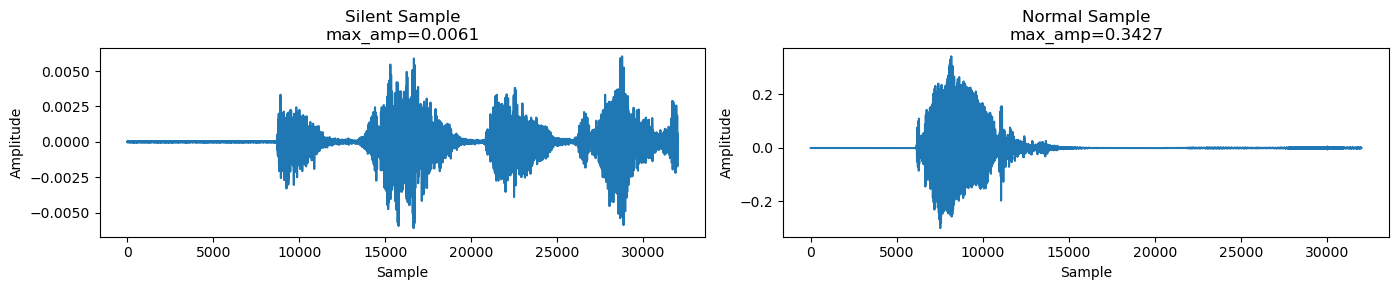

Silent file -> child: sham | RMS: 0.00087


Normal file -> child: adam khatab | RMS: 0.03995



CLASS: Masjed


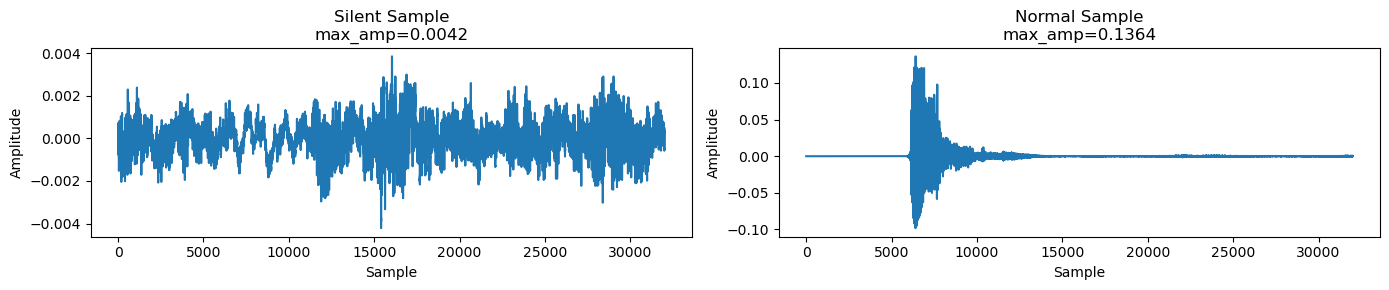

Silent file -> child: hala | RMS: 0.00079


Normal file -> child: adam khatab | RMS: 0.00928



CLASS: Halib


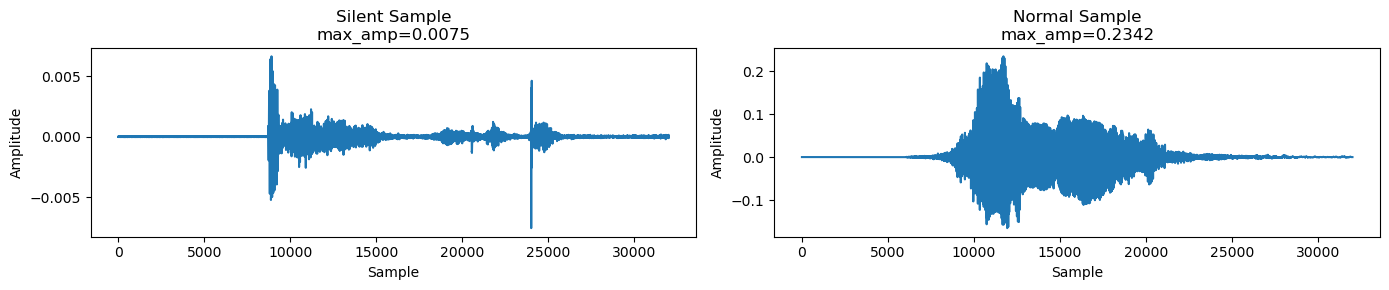

Silent file -> child: julia | RMS: 0.00051


Normal file -> child: Alif_ameraboqasem | RMS: 0.03132


In [59]:
# compare before removing silent files
from IPython.display import Audio, display

def inspect_silent_vs_normal(
    words_data,
    words_path,
    n_samples=5,
    random_state=42
):
    silent_files = words_data[
        words_data["is_silent"] == True
    ]

    if len(silent_files) == 0:
        print("No silent files found.")
        return
    # Sample across different classes when possible, not just the first N rows
    sample = silent_files.sample(
        n=min(n_samples, len(silent_files)),
        random_state=random_state
    )

    for _, silent_row in sample.iterrows():

        class_name = silent_row["class"]

        normal_candidates = words_data[
            (words_data["class"] == class_name) &
            (words_data["is_silent"] == False)
        ]

        if len(normal_candidates) == 0:
            print(
                f"No normal reference found "
                f"for class '{class_name}'"
            )
            continue

        normal_row = normal_candidates.iloc[0]

        silent_path = os.path.join(
            words_path,
            class_name,
            silent_row["file_name"]
        )

        normal_path = os.path.join(
            words_path,
            class_name,
            normal_row["file_name"]
        )

        silent_wave, sr_s = librosa.load(
            silent_path,
            sr=None,
            mono=True
        )

        normal_wave, sr_n = librosa.load(
            normal_path,
            sr=None,
            mono=True
        )

        print("\n" + "=" * 60)
        print(f"CLASS: {class_name}")
        print("=" * 60)

        fig, axes = plt.subplots(
            1, 2,
            figsize=(14, 3)
        )

        axes[0].plot(silent_wave)
        axes[0].set_title(
            f"Silent Sample\n"
            f"max_amp={silent_row['max_amplitude']:.4f}"
        )
        axes[0].set_xlabel("Sample")
        axes[0].set_ylabel("Amplitude")

        axes[1].plot(normal_wave)
        axes[1].set_title(
            f"Normal Sample\n"
            f"max_amp={normal_row['max_amplitude']:.4f}"
        )
        axes[1].set_xlabel("Sample")
        axes[1].set_ylabel("Amplitude")

        plt.tight_layout()
        plt.show()

        print(
            "Silent file ->",
            "child:", silent_row["child_id"],
            "| RMS:",
            round(silent_row["rms"], 5)
        )

        display(
            Audio(
                silent_wave,
                rate=sr_s
            )
        )

        print(
            "Normal file ->",
            "child:", normal_row["child_id"],
            "| RMS:",
            round(normal_row["rms"], 5)
        )

        display(
            Audio(
                normal_wave,
                rate=sr_n
            )
        )

# Run the inspection on 5 random silent samples across different classes
inspect_silent_vs_normal(
    words_data,
    words_path,
    n_samples=3
)

In [60]:
# delete silent files

def remove_silent_files(
    df,
    words_path
):
    silent_mask = df["is_silent"] == True
    silent_files = df[silent_mask]

    deleted_count = 0
    missing_count = 0
    error_count = 0

    for _, row in silent_files.iterrows():

        file_path = os.path.join(
            words_path,
            row["class"],
            row["file_name"]
        )

        try:

            if os.path.exists(file_path):

                os.remove(file_path)
                deleted_count += 1

            else:

                missing_count += 1

        except OSError as e:

            error_count += 1
            print(
                f"Error deleting "
                f"{file_path}: {e}"
            )

    df_clean = df[~silent_mask].reset_index(drop=True)

    print("========== SILENT FILES REMOVAL ==========")
    print("Silent files found:", len(silent_files))
    print("Deleted:", deleted_count)
    print("Already missing:", missing_count)
    print("Deletion errors:", error_count)
    print("Total files after cleaning:", len(df_clean))
    print("Remaining silent files:", df_clean["is_silent"].sum())

    return df_clean
#update dataset
words_data = remove_silent_files(
    words_data,
    words_path
)


========== SILENT FILES REMOVAL ==========
Silent files found: 89
Deleted: 89
Already missing: 0
Deletion errors: 0
Total files after cleaning: 8930
Remaining silent files: 0



     Analyze leading and trailing silence in an audio file.


In [61]:
from pathlib import Path

def analyze_silence(
    file_path,
    silence_threshold_db=30,
    min_silence_duration=0.1
):
    try:
        y, sr = librosa.load(
            file_path,
            sr=None,
            mono=True
        )

        duration = len(y) / sr

        # Detect non-silent intervals
        intervals = librosa.effects.split(
            y,
            top_db=silence_threshold_db
        )

        # Entire file is silent
        if len(intervals) == 0:
            return {
                "leading_silence_sec": duration,
                "trailing_silence_sec": duration,
                "speech_duration_sec": 0,
                "has_leading_silence": True,
                "has_trailing_silence": True,
                "status": "SILENT"
            }

        # First speech sample
        first_sound_start = intervals[0][0]

        # Last speech sample
        last_sound_end = intervals[-1][1]

        # Calculate durations
        leading_silence = first_sound_start / sr
        trailing_silence = (
            len(y) - last_sound_end
        ) / sr

        speech_duration = (
            last_sound_end - first_sound_start
        ) / sr

        return {
            "leading_silence_sec": leading_silence,
            "trailing_silence_sec": trailing_silence,
            "speech_duration_sec": speech_duration,

            "has_leading_silence": (
                leading_silence >= min_silence_duration
            ),

            "has_trailing_silence": (
                trailing_silence >= min_silence_duration
            ),

            "status": "OK"
        }

    except Exception as e:

        print(
            f"Error reading {file_path}: {e}"
        )

        return {
            "leading_silence_sec": np.nan,
            "trailing_silence_sec": np.nan,
            "speech_duration_sec": np.nan,
            "has_leading_silence": False,
            "has_trailing_silence": False,
            "status": "ERROR"
        }


In [62]:
silence_results = []

total_files = len(words_data)

for i, (_, row) in enumerate(
    words_data.iterrows(),
    start=1
):

    file_path = (
        Path(words_path)
        / row["class"]
        / row["file_name"]
    )

    if not file_path.exists():
        continue

    result = analyze_silence(
        file_path,
        silence_threshold_db=30,
        min_silence_duration=0.1
    )

    result["class"] = row["class"]
    result["file_name"] = row["file_name"]

    silence_results.append(result)

    if i % 1000 == 0:
        print(
            f"Checked {i} / {total_files} files"
        )
print("Quality check completed on", total_files, "files")

# Create DataFrame

silence_df = pd.DataFrame(silence_results)

print("\n========== SILENCE ANALYSIS ==========")

print(
    "Files analyzed:",
    len(silence_df)
)

print(
    "Leading silence:",
    silence_df["has_leading_silence"].sum()
)

print(
    "Trailing silence:",
    silence_df["has_trailing_silence"].sum()
)

print(
    "Errors:",
    (silence_df["status"] == "ERROR").sum()
)

Checked 1000 / 8930 files
Checked 2000 / 8930 files
Checked 3000 / 8930 files
Checked 4000 / 8930 files
Checked 5000 / 8930 files
Checked 6000 / 8930 files
Checked 7000 / 8930 files
Checked 8000 / 8930 files
Quality check completed on 8930 files

========== SILENCE ANALYSIS ==========
Files analyzed: 8930
Leading silence: 6095
Trailing silence: 5030
Errors: 0


In [63]:
print("\nLeading Silence Statistics:")
print(
    silence_df["leading_silence_sec"].describe()
)

print("\nTrailing Silence Statistics:")
print(
    silence_df["trailing_silence_sec"].describe()
)

print("\nSpeech Duration Statistics:")
print(
    silence_df["speech_duration_sec"].describe()
)


Leading Silence Statistics:
count    8930.000000
mean        0.381115
std         0.307632
min         0.000000
25%         0.000000
50%         0.416000
75%         0.544000
max         1.600000
Name: leading_silence_sec, dtype: float64

Trailing Silence Statistics:
count    8930.000000
mean        0.387487
std         0.408536
min         0.000000
25%         0.000000
50%         0.240000
75%         0.752000
max         1.840000
Name: trailing_silence_sec, dtype: float64

Speech Duration Statistics:
count    8930.000000
mean        1.230978
std         0.599609
min         0.125000
25%         0.672000
50%         1.088000
75%         2.000000
max         2.000000
Name: speech_duration_sec, dtype: float64


    Trim Silence

In [64]:
original_path = Path(words_path)

trimmed_path = (
    original_path.parent
    / "abjad_words_trimmed"
)

trimmed_path.mkdir(
    parents=True,
    exist_ok=True
)


def trim_silence(
    y,
    sr,
    silence_threshold_db=30,
    pad_sec=0.05
):

    intervals = librosa.effects.split(
        y,
        top_db=silence_threshold_db
    )

    if len(intervals) == 0:
        return None, "SILENT"

    pad_samples = int(
        pad_sec * sr
    )

    start = max(
        0,
        intervals[0][0] - pad_samples
    )

    end = min(
        len(y),
        intervals[-1][1] + pad_samples
    )

    return (
        y[start:end],
        "OK"
    )

In [65]:
trimmed_results = []

silent_skipped_count = 0
error_count = 0
missing_count = 0

total_files = len(words_data)


for i, (_, row) in enumerate(
    words_data.iterrows(),
    start=1
):

    class_name = row["class"]
    file_name = row["file_name"]

    original_file = (
        Path(words_path)
        / class_name
        / file_name
    )

    output_dir = (
        trimmed_path
        / class_name
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    output_file = (
        output_dir
        / file_name
    )

    if not original_file.exists():

        missing_count += 1
        continue

    try:

        y_original, sr = librosa.load(
            original_file,
            sr=None,
            mono=True
        )

        original_duration = (
            len(y_original) / sr
        )

        y_trimmed, status = trim_silence(
            y_original,
            sr,
            silence_threshold_db=30,
            pad_sec=0.05
        )

        if status == "SILENT":

            silent_skipped_count += 1
            continue

        trimmed_duration = (
            len(y_trimmed) / sr
        )

        removed_silence = (
            original_duration
            - trimmed_duration
        )

        sf.write(
            output_file,
            y_trimmed,
            sr
        )

        result = row.to_dict()

        result.update({
            "original_duration":
                original_duration,

            "trimmed_duration":
                trimmed_duration,

            "removed_silence":
                removed_silence,

            "trim_status":
                status
        })

        trimmed_results.append(
            result
        )

    except Exception as e:

        error_count += 1

        print(
            f"Error processing "
            f"{file_name}: {e}"
        )

    if i % 1000 == 0:

        print(
            f"Processed "
            f"{i} / {total_files} files"
        )


Processed 1000 / 8930 files
Processed 2000 / 8930 files
Processed 3000 / 8930 files
Processed 4000 / 8930 files
Processed 5000 / 8930 files
Processed 6000 / 8930 files
Processed 7000 / 8930 files
Processed 8000 / 8930 files


In [67]:
trimmed_df = pd.DataFrame(
    trimmed_results
)

print("\n========== TRIMMING SUMMARY ==========")

print("Total files in metadata:",total_files)

print("Files processed successfully:",len(trimmed_df))

print("Silent files skipped:",silent_skipped_count)

print("Missing files:",missing_count)

print("Errors:",error_count)

if len(trimmed_df) > 0:

    print(
        "Original average duration:",
        round(
            trimmed_df[
                "original_duration"
            ].mean(),
            3
        ),
        "seconds"
    )

    print(
        "Trimmed average duration:",
        round(
            trimmed_df[
                "trimmed_duration"
            ].mean(),
            3
        ),
        "seconds"
    )

    print(
        "Average removed silence:",
        round(
            trimmed_df[
                "removed_silence"
            ].mean(),
            3
        ),
        "seconds"
    )

print(
    "\nTrimmed dataset shape:",
    trimmed_df.shape
)

print(
    "\nTrimmed dataset columns:"
)

print(
    trimmed_df.columns.tolist()
)


========== TRIMMING SUMMARY ==========
Total files in metadata: 8930
Files processed successfully: 8930
Silent files skipped: 0
Missing files: 0
Errors: 0
Original average duration: 2.0 seconds
Trimmed average duration: 1.296 seconds
Average removed silence: 0.703 seconds

Trimmed dataset shape: (8930, 17)

Trimmed dataset columns:
['class', 'file_name', 'child_id', 'recording_id', 'copy_num', 'file_hash', 'sample_rate', 'duration', 'channels', 'max_amplitude', 'rms', 'is_silent', 'status', 'original_duration', 'trimmed_duration', 'removed_silence', 'trim_status']


     Waveform comparison 


Class: Shajara
File: Shajara_salam_3d1c656f-4f76-47bb-aca3-4240a5353490.wav
Child: salam

Original:
Sample Rate: 16000 Hz
Duration: 2.000 sec

Trimmed:
Sample Rate: 16000 Hz
Duration: 1.026 sec

Removed Silence: 0.974 sec


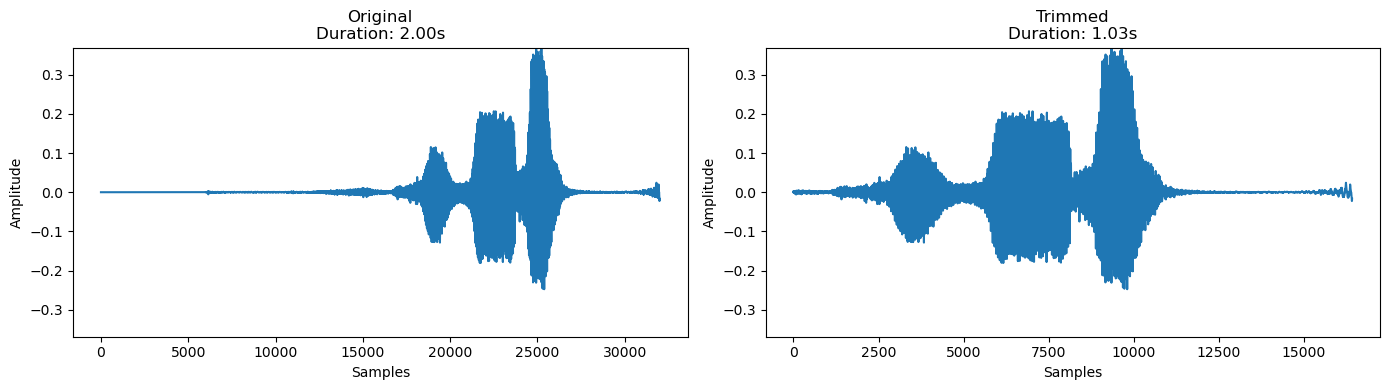

 Original Audio:


 Trimmed Audio:



Class: Feel
File: Feel_maisam_757ba15c-06b5-4c93-a9f0-800226d8b5f2.wav
Child: maisam

Original:
Sample Rate: 16000 Hz
Duration: 2.000 sec

Trimmed:
Sample Rate: 16000 Hz
Duration: 0.772 sec

Removed Silence: 1.228 sec


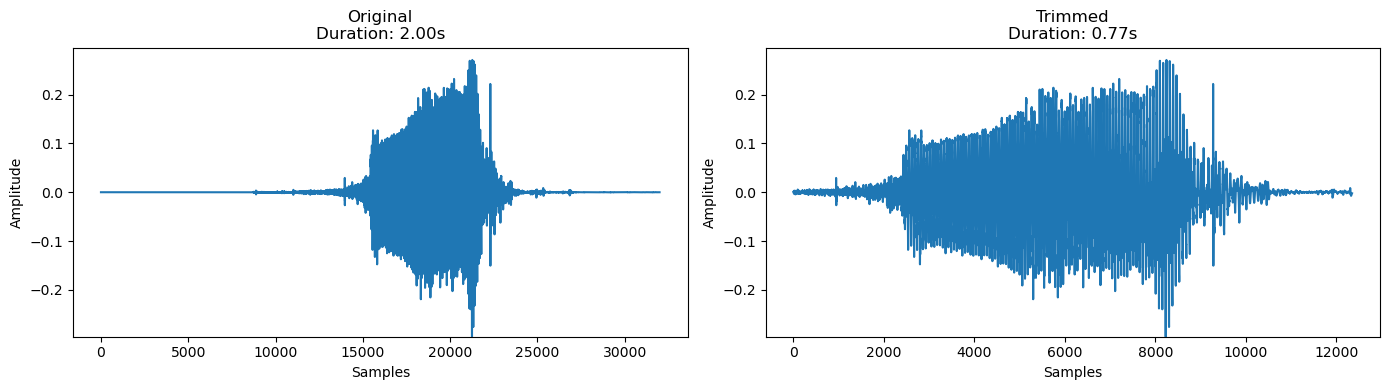

 Original Audio:


 Trimmed Audio:



Class: Feel
File: Feel_sila_e5d759b9-c0c0-450a-a54c-e0fe2467bc14.wav
Child: sila

Original:
Sample Rate: 16000 Hz
Duration: 2.000 sec

Trimmed:
Sample Rate: 16000 Hz
Duration: 0.644 sec

Removed Silence: 1.356 sec


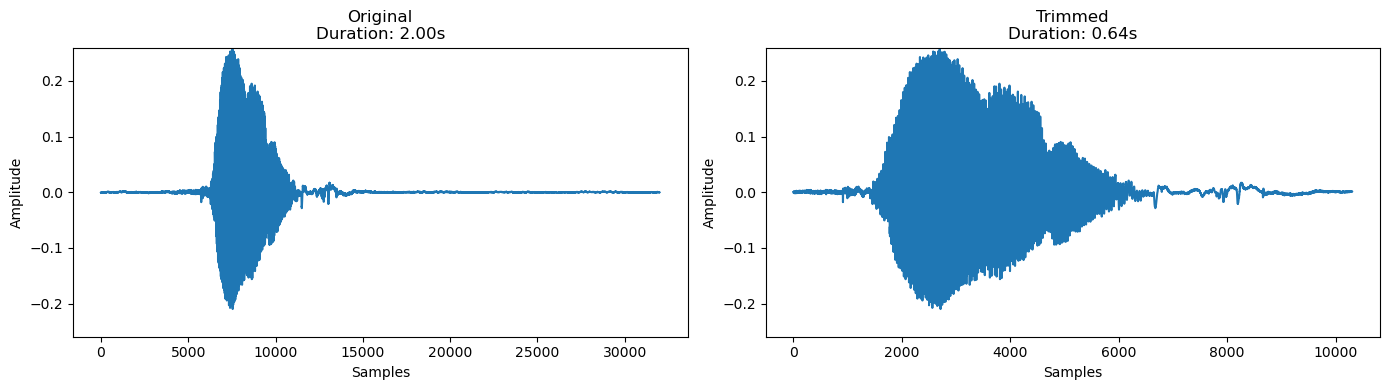

 Original Audio:


 Trimmed Audio:


In [68]:
def compare_original_vs_trimmed(
    df,
    original_path,
    trimmed_path,
    n_samples=5,
    random_state=42
):
    samples = df.sample(n=min(n_samples, len(df)), random_state=random_state)

    for _, row in samples.iterrows():
        class_name = row["class"]
        file_name = row["file_name"]

        original_file = Path(original_path) / class_name / file_name
        trimmed_file = Path(trimmed_path) / class_name / file_name

        if not original_file.exists() or not trimmed_file.exists():
            print(f"Skipping {file_name}: file(s) not found")
            continue

        y_original, sr_original = librosa.load(original_file, sr=None, mono=True)
        y_trimmed, sr_trimmed = librosa.load(trimmed_file, sr=None, mono=True)

        original_duration = len(y_original) / sr_original
        trimmed_duration = len(y_trimmed) / sr_trimmed

        print("\n" + "=" * 70)
        print(f"Class: {class_name}")
        print(f"File: {file_name}")
        if "child_id" in row:
            print(f"Child: {row['child_id']}")

        print("\nOriginal:")
        print(f"Sample Rate: {sr_original} Hz")
        print(f"Duration: {original_duration:.3f} sec")

        print("\nTrimmed:")
        print(f"Sample Rate: {sr_trimmed} Hz")
        print(f"Duration: {trimmed_duration:.3f} sec")

        print(f"\nRemoved Silence: {original_duration - trimmed_duration:.3f} sec")

        # Waveform comparison 
        y_max = max(np.abs(y_original).max(), np.abs(y_trimmed).max())

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        axes[0].plot(y_original)
        axes[0].set_title(f"Original\nDuration: {original_duration:.2f}s")
        axes[0].set_xlabel("Samples")
        axes[0].set_ylabel("Amplitude")
        axes[0].set_ylim(-y_max, y_max)

        axes[1].plot(y_trimmed)
        axes[1].set_title(f"Trimmed\nDuration: {trimmed_duration:.2f}s")
        axes[1].set_xlabel("Samples")
        axes[1].set_ylabel("Amplitude")
        axes[1].set_ylim(-y_max, y_max)

        plt.tight_layout()
        plt.show()

        print(" Original Audio:")
        display(Audio(y_original, rate=sr_original))

        print(" Trimmed Audio:")
        display(Audio(y_trimmed, rate=sr_trimmed))


# Run comparison
compare_original_vs_trimmed(
    trimmed_df,
    words_path,
    trimmed_path,
    n_samples=3,
    random_state=42
)

In [69]:
# Final Verification of Trimmed Dataset

quality_results = []

missing_files = 0
error_count = 0

total_files = len(trimmed_df)

for i, (_, row) in enumerate(
    trimmed_df.iterrows(),
    start=1
):

    file_path = (
        Path(trimmed_path)
        / row["class"]
        / row["file_name"]
    )

    if not file_path.exists():

        missing_files += 1
        continue

    try:

        y, sr = librosa.load(
            file_path,
            sr=None,
            mono=True
        )

        duration = len(y) / sr

        max_amplitude = np.max(
            np.abs(y)
        )

        rms = np.sqrt(
            np.mean(y ** 2)
        )

        result = row.to_dict()

        result.update({
            "final_sample_rate": sr,
            "final_duration": duration,
            "final_max_amplitude": max_amplitude,
            "final_rms": rms,
            "final_is_silent": (
                max_amplitude < 1e-4
            )
        })

        quality_results.append(
            result
        )

    except Exception as e:

        error_count += 1

        print(
            f"Error processing: "
            f"{file_path}"
        )

        print(e)

    if i % 1000 == 0:

        print(
            f"Checked "
            f"{i} / {total_files} files"
        )


Checked 1000 / 8930 files
Checked 2000 / 8930 files
Checked 3000 / 8930 files
Checked 4000 / 8930 files
Checked 5000 / 8930 files
Checked 6000 / 8930 files
Checked 7000 / 8930 files
Checked 8000 / 8930 files


In [70]:
# Create Final Verification DataFrame

final_quality_df = pd.DataFrame(
    quality_results
)

print("========== FINAL DATASET VERIFICATION ==========")
print("Original files:", total_files)
print("Successfully verified:", len(final_quality_df))
print("Missing files:", missing_files)
print("Errors:", error_count)
print("\nClasses:", final_quality_df["class"].nunique())
print("Children:", final_quality_df["child_id"].nunique())


========== FINAL DATASET VERIFICATION ==========
Original files: 8930
Successfully verified: 8930
Missing files: 0
Errors: 0

Classes: 55
Children: 164


In [71]:
# Sample Rate

print("\nSample Rate:")
print(final_quality_df["sample_rate"].value_counts().sort_index())

# Duration Statistics

print("\nDuration Statistics:")
print(final_quality_df["duration"].describe())



Sample Rate:
sample_rate
16000    8930
Name: count, dtype: int64

Duration Statistics:
count    8930.000000
mean        1.999580
std         0.028059
min         0.125000
25%         2.000000
50%         2.000000
75%         2.000000
max         2.000000
Name: duration, dtype: float64


In [72]:
# Silent Files

print(
    "\nSilent files:",
    final_quality_df[
        "final_is_silent"
    ].sum()
)

# Very Short Files

very_short = final_quality_df[
    final_quality_df[
        "final_duration"
    ] < 0.3
]

print(
    "\nFiles shorter than 0.3 sec:",
    len(very_short)
)

# Class Distribution

class_counts = (
    final_quality_df["class"]
    .value_counts()
)

print(
    "\nFiles per class:"
)

print(
    class_counts.describe()
)



Silent files: 0

Files shorter than 0.3 sec: 3

Files per class:
count     55.000000
mean     162.363636
std       25.498993
min       35.000000
25%      167.000000
50%      169.000000
75%      170.000000
max      180.000000
Name: count, dtype: float64


In [73]:
# Class Imbalance
print(
    "\nMinimum files in a class:",
    class_counts.min()
)

print(
    "Maximum files in a class:",
    class_counts.max()
)


Minimum files in a class: 35
Maximum files in a class: 180


    split data to train/val/test

In [74]:
from sklearn.model_selection import train_test_split

# Get unique children
unique_children = trimmed_df["child_id"].unique()

# 70% Train, 30% Temporary
train_children, temp_children = train_test_split(
    unique_children,
    test_size=0.3,
    random_state=42
)

# 15% Validation, 15% Test
val_children, test_children = train_test_split(
    temp_children,
    test_size=0.5,
    random_state=42
)

# Assign split based on child_id
trimmed_df["split"] = trimmed_df["child_id"].apply(
    lambda x: "train" if x in train_children
    else "val" if x in val_children
    else "test"
)

print("========== SPLIT SUMMARY ==========")

print("\nFiles per split:")
print(trimmed_df["split"].value_counts())

print("\nChildren per split:")
print(
    trimmed_df.groupby("split")["child_id"]
    .nunique()
)

print("\nClasses per split:")
print(
    trimmed_df.groupby("split")["class"]
    .nunique()
)

========== SPLIT SUMMARY ==========

Files per split:
split
train    6003
val      1567
test     1360
Name: count, dtype: int64

Children per split:
split
test      25
train    114
val       25
Name: child_id, dtype: int64

Classes per split:
split
test     55
train    55
val      55
Name: class, dtype: int64


In [78]:
print("Columns:")
print(trimmed_df.columns.tolist())

print("\nFirst 5 rows:")
display(trimmed_df.head(5))

Columns:
['class', 'file_name', 'child_id', 'recording_id', 'copy_num', 'file_hash', 'sample_rate', 'duration', 'channels', 'max_amplitude', 'rms', 'is_silent', 'status', 'original_duration', 'trimmed_duration', 'removed_silence', 'trim_status', 'split']

First 5 rows:


,class,file_name,child_id,recording_id,copy_num,file_hash,sample_rate,duration,channels,max_amplitude,rms,is_silent,status,original_duration,trimmed_duration,removed_silence,trim_status,split
0,Alam,Alam_adam khatab_b5cf27cc-0748-484e-95f3-59c81...,adam khatab,b5cf27cc-0748-484e-95f3-59c81ae94514,1,66046008dd77a5aaab44cfc53094f7ec,16000,2.0,1,0.833710,0.081379,False,OK,2.0,0.74,1.26,OK,train
1,Alam,Alam_bilad_1c5b4960-2f93-45e7-bae2-b0dd175990c...,bilad,1c5b4960-2f93-45e7-bae2-b0dd175990c4,1,08dbb6416576fdd81d66b90c3435383b,16000,2.0,1,0.312988,0.025220,False,OK,2.0,2.00,0.00,OK,train
2,Alam,Alam_bilad_a266a5d9-976d-4b7b-b749-9dfabe4f039...,bilad,a266a5d9-976d-4b7b-b749-9dfabe4f0395,1,4da90a9d247329991ae877c5326c09a0,16000,2.0,1,0.471497,0.030623,False,OK,2.0,2.00,0.00,OK,train
3,Alam,Alam_fahd_000e62c5-9013-4736-b25b-b806d4f126c3...,fahd,000e62c5-9013-4736-b25b-b806d4f126c3,1,28ed6559bdd37252428c6518cf281691,16000,2.0,1,1.000000,0.088109,False,OK,2.0,2.00,0.00,OK,test
4,Alam,Alam_fahd_e971457c-c41b-47fa-a99d-5b9df41817ec...,fahd,e971457c-c41b-47fa-a99d-5b9df41817ec,1,acc3e4ec84d6cfa5c5b8230485bd5b8a,16000,2.0,1,0.762238,0.079421,False,OK,2.0,2.00,0.00,OK,test


    Padding / Truncation Function

In [80]:
from pathlib import Path

TARGET_SR = 16000
TARGET_DURATION = 2.0
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

In [81]:
def pad_or_truncate(
    y,
    target_length=TARGET_LENGTH,
    mode="post"
):
    current_length = len(y)

    # Truncation
    if current_length > target_length:
        y = y[:target_length]

    # Padding
    elif current_length < target_length:

        pad_amount = target_length - current_length

        if mode == "post":
            y = np.pad(
                y,
                (0, pad_amount),
                mode="constant"
            )

        elif mode == "center":
            pad_left = pad_amount // 2
            pad_right = pad_amount - pad_left

            y = np.pad(
                y,
                (pad_left, pad_right),
                mode="constant"
            )

        else:
            raise ValueError(
                "mode must be 'post' or 'center'"
            )

    return y

In [82]:
# Apply Padding / Truncation
def prepare_audio_dataset(
    df,
    audio_path,
    target_sr=TARGET_SR,
    target_length=TARGET_LENGTH,
    mode="post"
):
    audio_arrays = []
    data = []

    errors = 0
    missing_files = 0
    total_files = len(df)

    for i, (_, row) in enumerate(
        df.iterrows(),
        start=1
    ):
        class_name = row["class"]
        file_name = row["file_name"]

        file_path = (
            Path(audio_path)
            / class_name
            / file_name
        )

        if not file_path.exists():
            missing_files += 1
            continue

        try:
            # Load trimmed audio
            y, sr = librosa.load(
                file_path,
                sr=target_sr,
                mono=True
            )

            # Apply padding / truncation
            y_fixed = pad_or_truncate(
                y,
                target_length=target_length,
                mode=mode
            )

            audio_arrays.append(y_fixed)

            data.append({
                "class": row["class"],
                "file_name": row["file_name"],
                "child_id": row["child_id"],
                "split": row["split"]
            })

        except Exception as e:
            errors += 1
            print(
                f"Error processing {file_path}: {e}"
            )

        if i % 1000 == 0:
            print(
                f"Processed {i} / {total_files} files"
            )

    # Convert to NumPy array
    X = np.array(
        audio_arrays,
        dtype=np.float32
    )

    # Metadata corresponding to X
    data_df = pd.DataFrame(data)

    print(
        "\n========== PADDING / TRUNCATION SUMMARY =========="
    )
    print("Original files:", total_files)
    print("Successfully processed:", len(X))
    print("Missing files:", missing_files)
    print("Errors:", errors)
    print("X shape:", X.shape)
    print(
        "Expected shape:",
        (len(X), target_length)
    )
    print("Sample rate:", target_sr)
    print(
        "Target duration:",
        target_length / target_sr,
        "seconds"
    )

    return X, data_df

In [83]:
X, audio_metadata = prepare_audio_dataset(
    df=trimmed_df,
    audio_path=trimmed_path,
    target_sr=TARGET_SR,
    target_length=TARGET_LENGTH,
    mode="post"
)

Processed 1000 / 8930 files
Processed 2000 / 8930 files
Processed 3000 / 8930 files
Processed 4000 / 8930 files
Processed 5000 / 8930 files
Processed 6000 / 8930 files
Processed 7000 / 8930 files
Processed 8000 / 8930 files

========== PADDING / TRUNCATION SUMMARY ==========
Original files: 8930
Successfully processed: 8930
Missing files: 0
Errors: 0
X shape: (8930, 32000)
Expected shape: (8930, 32000)
Sample rate: 16000
Target duration: 2.0 seconds


    Prepare / Separate the already-defined splits


In [84]:
train_mask = audio_metadata["split"] == "train"
val_mask = audio_metadata["split"] == "val"
test_mask = audio_metadata["split"] == "test"

X_train = X[train_mask.values]
X_val = X[val_mask.values]
X_test = X[test_mask.values]

y_train = audio_metadata.loc[
    train_mask,
    "class"
].values

y_val = audio_metadata.loc[
    val_mask,
    "class"
].values

y_test = audio_metadata.loc[
    test_mask,
    "class"
].values

print("\n========== FINAL DATA SPLIT ==========")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


========== FINAL DATA SPLIT ==========
X_train: (6003, 32000)
y_train: (6003,)
X_val: (1567, 32000)
y_val: (1567,)
X_test: (1360, 32000)
y_test: (1360,)


# label encoding

In [86]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

le.fit(audio_metadata["class"])

y_train_encoded = le.transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

print("========== LABEL ENCODING CHECK ==========")

print("Number of classes:", len(le.classes_))

print("Train unique labels:", len(set(y_train_encoded)))
print("Val unique labels:", len(set(y_val_encoded)))
print("Test unique labels:", len(set(y_test_encoded)))

print("\nTrain shape:", y_train_encoded.shape)
print("Val shape:", y_val_encoded.shape)
print("Test shape:", y_test_encoded.shape)

========== LABEL ENCODING CHECK ==========
Number of classes: 55
Train unique labels: 55
Val unique labels: 55
Test unique labels: 55

Train shape: (6003,)
Val shape: (1567,)
Test shape: (1360,)
